# DL 2022-2023 Carolo Maine

# Imports

In [1]:
import pickle # Load refs and annotations
import json
import os
import pandas as pd
import numpy as np
import pprint
import json
import cv2
import random

from typing import Any, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.utils.tensorboard import SummaryWriter

import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import v2
from torchvision.utils import draw_bounding_boxes
from torchvision import models
import torchmetrics

import pytorch_lightning as pl
from pytorch_lightning.utilities.types import STEP_OUTPUT

from transformers import T5Tokenizer, T5ForConditionalGeneration
from transformers import CLIPProcessor, CLIPModel

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import clip
from ultralytics import YOLO
from PIL import Image, ImageDraw

from ipywidgets import FloatProgress
import math 
from torch.nn.modules.batchnorm import _BatchNorm
from torchvision.ops import box_convert
from datetime import datetime
from torch.profiler import profile, record_function, ProfilerActivity

In [2]:
%load_ext tensorboard

# Utils

In [3]:
# if torch.backends.mps.is_available():
#     print("MPS backend is available.")
#     device = torch.device('mps')
if torch.cuda.is_available():
    print("CUDA backend is available.")
    device = torch.device('cuda')
else:
    print("Neither CUDA or MPS backend are available. Resorting to CPU")
    device = torch.device('cpu')

Neither CUDA or MPS backend are available. Resorting to CPU


In [4]:
log_dir = 'logs'

In [5]:
def plot_images(images):
    num_images = len(images)
    cols = 3  # Number of columns in the grid
    rows = (num_images // cols) + (num_images % cols > 0)

    # Create a figure to display the images
    plt.figure(figsize=(15, 5 * rows))

    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')  # Hide axes

    plt.show()

In [6]:
def draw_bboxes(image_path, bbox, gt, confidence):
    image = cv2.imread(image_path)

    # Define colors
    max_bbox_color = (0, 255, 0)  # Green for ground truth
    other_bbox_color = (0, 0, 255)  # Red for predictions

    # Plot all bboxes
    cv2.rectangle(image, (int(bbox[0]), int(bbox[1])) ,(int(bbox[2]), int(bbox[3])), other_bbox_color, 2)
    cv2.putText(image, 'Confiddence' + str(confidence), (int(bbox[0]), int(bbox[1])-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, other_bbox_color, 2)
    color = max_bbox_color
    cv2.rectangle(image, (int(gt[0]), int(gt[1])) ,(int(gt[2]), int(gt[3])), color, 2)

    # Convert the image from BGR to RGB for displaying with matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image_rgb

In [7]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection_area = max(0, x2 - x1 + 1) * max(0, y2 - y1 + 1) # +1 to avoid max(0,0) therefore avoiding 

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    union_area = box1_area + box2_area - intersection_area

    return intersection_area / union_area

In [8]:
class MetricMeter:
    def __init__(self, name="Default", threshold = 0.5, log_dir='./logs/default_run'):
        self.name = name
        self.metrics = []
        self.epochs = []
        self.threshold = threshold
        self.reset()
        self.best_cases_iou = []  # To store the best cases
        self.worst_cases_iou = []
        self.best_cases_sim = []  # To store the best cases
        self.worst_cases_sim = []
        self.writer = SummaryWriter(log_dir=log_dir)

# TODO add SummaryWriter to plot

    def reset(self):
        self.count = 0
        self.iou = 0
        self.epoch = 0
        self.correct_bboxes, self.overall = 0,0
        self.semantic = 0
        self.metrics = []
    
    def add_best_iou(self, item):
        if len(self.best_cases_iou) < 5:
            self.best_cases_iou.append(item)
        else:
            min_best_case = min(self.best_cases_iou, key=lambda x: (x['iou']))
            if item['iou'] > min_best_case['iou']:
                self.best_cases_iou.remove(min_best_case)
                self.best_cases_iou.append(item)
    
    def add_worst_iou(self, item):
        if len(self.worst_cases_iou) < 5:
            self.worst_cases_iou.append(item)
        else:
            max_worst_case = max(self.worst_cases_iou, key=lambda x: (x['iou']))
            if (item['iou'] < max_worst_case['iou']):
                self.worst_cases_iou.remove(max_worst_case)
                self.worst_cases_iou.append(item)
    
    def add_best_confidence(self, item):
        if len(self.best_cases_sim) < 5:
            self.best_cases_sim.append(item)
        else:
            min_best_case = min(self.best_cases_sim, key=lambda x: (x['confidence']))
            if item['confidence'] > min_best_case['confidence']:
                self.best_cases_sim.remove(min_best_case)
                self.best_cases_sim.append(item)
    
    def add_worst_confidence(self, item):
        if len(self.worst_cases_sim) < 5:
            self.worst_cases_sim.append(item)
        else:
            max_worst_case = max(self.worst_cases_sim, key=lambda x: (x['confidence']))
            if (item['confidence'] < max_worst_case['confidence']):
                self.worst_cases_sim.remove(max_worst_case)
                self.worst_cases_sim.append(item)


    def update(self, iou, confidence,filename,bbox_e,bbox_gt):
        self.count += 1
        self.iou += iou
        if(iou >= self.threshold):
            self.correct_bboxes += 1
        self.semantic += confidence

        iteration = {
            'run_loc_acc': self.iou / self.count,
            'run_gro_acc': self.correct_bboxes / self.count,
            'run_sem_acc': self.semantic / self.count,
        }

        item = {
            'iou': iou,
            'confidence':confidence,
            'ground_truth': bbox_gt,
            'candidate': bbox_e,
            'path':filename
        }
        self.metrics.append([iteration])
        self.add_best_confidence(item)
        self.add_worst_confidence(item)
        self.add_best_iou(item)
        self.add_worst_iou(item)
        self.writer.add_scalar('Localization Loss', self.iou / self.count, self.count)
        self.writer.add_scalar('Grounding Accuracy',  self.correct_bboxes / self.count, self.count)
        self.writer.add_scalar('Semantic Similarity', self.semantic / self.count, self.count)

    def new_epoch(self):
        self.epoch += 1
        self.writer.add_scalar('Localization Loss', self.iou / self.count, self.epoch)
        self.writer.add_scalar('Grounding Accuracy',  self.correct_bboxes / self.count, self.epoch)
        self.writer.add_scalar('Semantic Similarity', self.semantic / self.count, self.epoch)
        self.epochs.append(self.metrics,self.best_cases_iou,self.best_cases_sim,self.worst_cases_iou,self.worst_cases_sim)
        self.reset()

    def __repr__(self):
        text = f"{self.name}: {self.avg:.8f}"
        return text
    
    def print_iteration(self):
        print(f"Localization accuracy = {self.iou / self.count}, Grounding Accuracy = {self.correct_bboxes / self.count}, Semantic Similarity = {self.semantic / self.count}")

    def get_best_iou_cases(self):
        return sorted(self.best_cases_iou, key=lambda x: x['iou'], reverse=True)

    def get_worst_iou_cases(self):
        return sorted(self.worst_cases_iou, key=lambda x: x['iou'])

    def get_best_pred_cases(self):
        return sorted(self.best_cases_sim, key=lambda x: x['confidence'], reverse=True)

    def get_worst_pred_cases(self):
        return sorted(self.worst_cases_sim, key=lambda x: x['confidence'])
    
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

# Dataset

In [9]:
with open("./refcocog/annotations/refs(umd).p", "rb") as fp:
  refs = pickle.load(fp)

# 'annotations' will be a dict object mapping the 'annotation_id' to the 'bbox' to make search faster
with open("./refcocog/annotations/instances.json", "rb") as fp:
  data = json.load(fp)
  annotations = dict(sorted({ann["id"]: ann["bbox"] for ann in data["annotations"]}.items()))

def getcaption(elem):
    li = []
    for e in elem["sentences"]:
        li.append(e['raw'])
    return li

In [10]:
def denormalize(image, mean, std):
    mean = torch.tensor(mean).reshape(1, 1, 3)  # Reshape to match (H, W, C)
    std = torch.tensor(std).reshape(1, 1, 3)
    denormalized_image = image * std + mean
    return denormalized_image

In [11]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]


In [12]:
class Denormalize:
    def __init__(self):
        clip_mean = [0.48145466, 0.4578275, 0.40821073]
        clip_std = [0.26862954, 0.26130258, 0.27577711]
        self.mean = torch.tensor(clip_mean).reshape(-1, 1, 1)  # Adjust shape to (H, W, C)
        self.std = torch.tensor(clip_std).reshape(-1, 1, 1)

    def __call__(self, tensor):
        # Denormalize the image tensor
        denormalized_tensor = tensor * self.std + self.mean
        return denormalized_tensor

In [13]:
class DataAugmentation():
# This class is used to perform tranformation in order to have augmented data
    
    def blur(self,img,bbox):
        # Gaussian Blur the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.GaussianBlur(kernel_size=5),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def rotate(self,img,bbox):
        # Rotate the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.RandomRotation(degrees=20),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox
    
    def grayscale(self,img,bbox):
        # Convert the image to grayscale
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Grayscale(num_output_channels=3),
            v2.ToTensor(),
            # since we do another manipulation we compute again the normalization 
            # of the image even tho clip does it before
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), 
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox
    
    def colorrand(self,img,bbox):
        # Randomly change the color of the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.ColorJitter(brightness=0.01*random.randrange(1,50), contrast=0.01*random.randrange(1,50), saturation=0.01*random.randrange(1,50), hue=0.01*random.randrange(1,50)),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox
    
    def Hflip(self,img,bbox):
        # flip horizontally both image and bbox
        #img = v2.functional.hflip(img)
        cxcywh_format = box_convert(bbox, 'xyxy', 'cxcywh')

        # flip the y coordinate
        transform = v2.Compose([
            v2.PILToTensor(),
            #Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.RandomHorizontalFlip(p=1),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        cxcywh_format[0] = img.shape[2] - cxcywh_format[0]

        bbox = box_convert(cxcywh_format, 'cxcywh', 'xyxy')
        return img, bbox

    def random_augmentation(self,img,bbox):
        # Randomly choose a transformation to be applied to the image
        n = random.randint(0, 4)
        if n == 0:
            return DataAugmentation.blur(self,img,bbox)
        elif n == 1:
            return DataAugmentation.Hflip(self,img,bbox)
        elif n == 2:
            return DataAugmentation.grayscale(self,img,bbox)
        elif n == 3:
            return DataAugmentation.colorrand(self,img,bbox)
        else:
            return DataAugmentation.Hflip(self,img,bbox)

In [14]:
clip_model, clip_preprocess = clip.load("RN50", device=device)

In [15]:

class RefCOCOG(Dataset):
    """
    Args:
        The dataset will be the raw data wothput any tipe of preprocessing
        {
            'file_name': 
            'caption':
            'ann_id': needed to extract the relative bbox from the .json file
            'bbox': values are set like following:
                - x 
                - y
                - width 
                - height
        }
    """
    def __init__(self, refs, model, preprocess, annotations, split="train", device = 'cuda', count = 5000):
        
        self.clip_model, self.clip_preprocess = model, preprocess
        self.device = device
        self.images = []
        self.texts = []
        self.filepaths =[]
        self.gt = []
        self.cls = []
        temp = 0
        for elem in [d for d in refs if d["split"]==split]:
            
            # Retrieve Single image
            file_name = os.path.join("./refcocog/images/", f'{"_".join(elem["file_name"].split("_")[:3])}.jpg')
            image = Image.open(file_name)

            # Retrieve possible ground truth measures
            cls = elem['category_id']
            gt = annotations[elem['ann_id']]
            bbox_tnsor = torch.tensor(gt, device=self.device)
            new_bbox = box_convert(bbox_tnsor, 'xywh', 'xyxy')
            # Get all texts related to the picture
            sentences = elem['sentences']
            # for i in sentences:
            self.texts.append(clip.tokenize(sentences[0]['raw']))
            self.images.append(self.clip_preprocess(image))
            self.gt.append(new_bbox)
            self.cls.append(cls)
            self.filepaths.append(file_name)
            # temp += 1
            # if (temp > count):
            #     break

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        images = self.images[idx]
        gt = self.gt[idx]
        cls = self.cls[idx]
        filename = self.filepaths[idx]
        return text, images, gt, cls, filename

    def __call__(self, idx):
        print(json.dumps(self.dataset[idx], indent=4))


The RefCOCOG_noproc is the dataset used in our locacl machines due to the restricted RAM size

In [16]:
class RefCOCOG_noproc(Dataset):
    """
    Args:
        The dataset will be the raw data wothput any tipe of preprocessing
        {
            'file_name': 
            'caption':
            'ann_id': needed to extract the relative bbox from the .json file
            'bbox': values are set like following:
                - x 
                - y
                - width 
                - height
        }
    """
    def __init__(self, refs, model, preprocess, annotations, split="train", device = 'cuda', count = 4):
        
        self.clip_model, self.clip_preprocess = model, preprocess
        self.device = device
        #self.images = []
        self.texts = []
        self.filepaths =[]
        self.gt = []
        self.cls = []
        self.AUG = DataAugmentation()


        temp = 0
        for elem in [d for d in refs if d["split"]==split]:
            
            # Retrieve Single image
            file_name = os.path.join("./refcocog/images/", f'{"_".join(elem["file_name"].split("_")[:3])}.jpg')
            #image = Image.open(file_name)

            # Retrieve possible ground truth measures
            cls = elem['category_id']
            gt = annotations[elem['ann_id']]
            bbox_tnsor = torch.tensor(gt, device=self.device)
            new_bbox = box_convert(bbox_tnsor, 'xywh', 'xyxy')
            # Get all texts related to the picture
            sentences = elem['sentences']
            # for i in sentences:
            self.texts.append(clip.tokenize(sentences[0]['raw']))
            #self.images.append(self.clip_preprocess(image))
            self.gt.append(new_bbox)
            self.cls.append(cls)
            self.filepaths.append(file_name)
            temp += 1
            if (temp > count):
                break

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        #images = self.images[idx]
        gt = self.gt[idx]
        cls = self.cls[idx]
        filename = self.filepaths[idx]
        image = Image.open(filename)
        #self.clip_preprocess(image)
        # Apply augmentations
        image = self.clip_preprocess(image).to(device)
        image, gt = self.AUG.random_augmentation(image,gt)
        #image = self.clip_preprocess(image).to(device)
        return text, gt, cls, filename, image

    def __call__(self, idx):
        print(json.dumps(self.dataset[idx], indent=4))


In [17]:
# create dataset and dataloader
print("----------------------Processing train split----------------------------")
dataset_train = RefCOCOG_noproc(refs, clip_model, clip_preprocess, annotations, device=device, split="train")
dataloader_train = DataLoader(dataset_train, batch_size=16)
len_train = len(dataset_train)
print(f"Numero esempi in train = {len_train}")

print("----------------------Processing test split-----------------------------")
dataset_test = RefCOCOG_noproc(refs, clip_model, clip_preprocess, annotations, device=device, split="test")
dataloader_test = DataLoader(dataset_test, batch_size=16)
len_test = len(dataset_test)
print(f"Numero esempi in train = {len_test}")

print("----------------------Processing eval split-----------------------------")
dataset_eval = RefCOCOG_noproc(refs, clip_model, clip_preprocess, annotations, device=device, split="val")
dataloader_eval = DataLoader(dataset_eval, batch_size=16)
len_eval = len(dataset_eval)
print(f"Numero esempi in eval = {len_eval}")

print("------------------------------------------------------------------------")


----------------------Processing train split----------------------------
Numero esempi in train = 5
----------------------Processing test split-----------------------------
Numero esempi in train = 5
----------------------Processing eval split-----------------------------
Numero esempi in eval = 5
------------------------------------------------------------------------


In [18]:
images = []
for text, gt, cls, filename, image in dataloader_eval:
    images = image
    break

/Users/mattiacarolo/.pyenv/versions/3.9.6/envs/bagigio/lib/python3.9/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


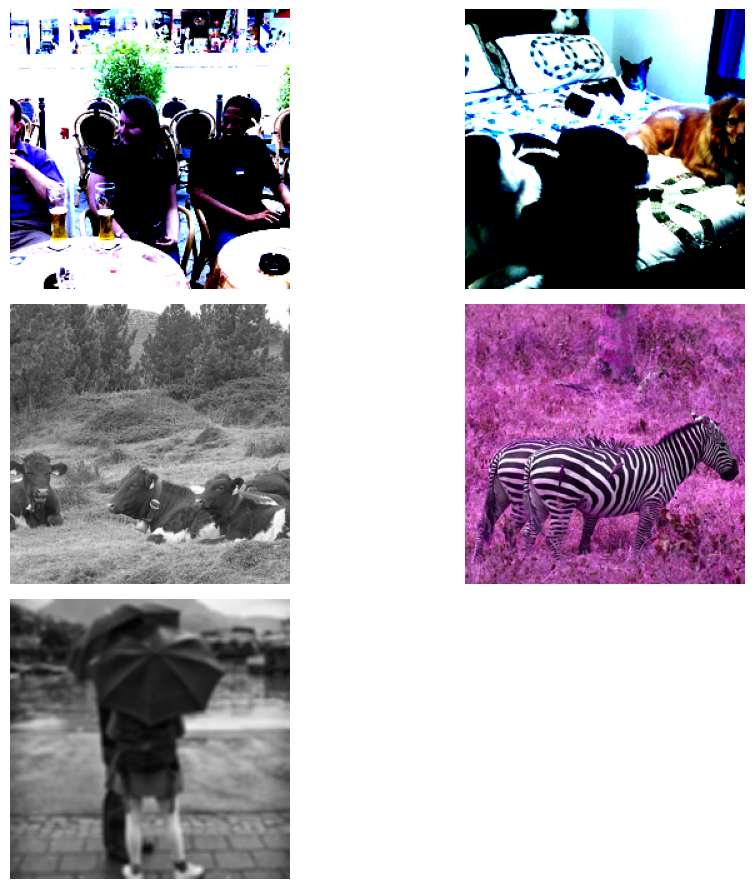

In [19]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Function to denormalize an image
def denormalize(image, mean, std):
    mean = torch.tensor(mean).reshape(1, 1, 3)  # Reshape to match (H, W, C)
    std = torch.tensor(std).reshape(1, 1, 3)
    denormalized_image = image * std + mean
    return denormalized_image
# Calculate the number of rows needed to display images in a 2-column layout
num_images = len(images)
num_cols = 2
num_rows = (num_images + num_cols - 1) // num_cols  # Ceiling division to get the required number of rows

# Set up the plot
plt.figure(figsize=(10, num_rows * 3))  # Adjust the figure size as needed

# Loop through and display each processed image in a grid with denormalization
for i, img in enumerate(images):
    # Denormalize the image
    img = img.permute(1, 2, 0)  # Convert (C, H, W) to (H, W, C)
    img = denormalize(img, mean, std)  # Apply denormalization
    img = torch.clip(img, 0, 1).numpy()  # Clip to valid range [0, 1] and convert to numpy for display

    # Add subplot in a 2-column grid
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img)
    plt.axis('off')  # Hide the axis

# Show the plot with all processed images
plt.tight_layout()
plt.show()

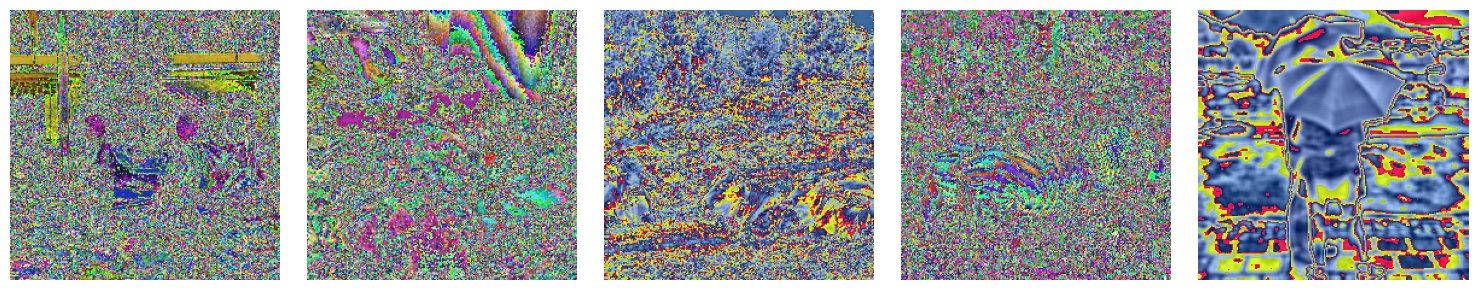

In [20]:
# Set up the plot
plt.figure(figsize=(15, 3))

# Loop through and display each processed image
for i, img in enumerate(images):
    # Check if the image is a tensor and convert it to a NumPy array if needed
    if isinstance(img, torch.Tensor):
        img = img.permute(1, 2, 0).numpy()  # Convert (C, H, W) to (H, W, C)
        img = (img * 255).astype('uint8')  # Convert to [0, 255] range for display

    # Add subplot
    plt.subplot(1, len(images), i + 1)
    plt.imshow(img)
    plt.axis('off')  # Hide the axis

# Show the plot with all processed images
plt.tight_layout()
plt.show()

# Zero-Shot Baseline

## Pipeline for zero-shotting

In [21]:
##########################################################
# YolottoClip - Just for Zero-Shotting the dataset
##########################################################

class YolottoClip():

    def __init__(self, clip_model, clip_preprocess):
        self.yolo = YOLO("yolov8n.pt")
        self.clip_model, self.clip_preprocess = clip_model, clip_preprocess

    def infer_bboxes(self, image_path):
        results = self.yolo(image_path, verbose=False)
        bboxes = results[0].boxes.xyxy
        return bboxes
    
    def preprocess_images(self, cropped_images):
        # preprocess with CLIP each cropped PIL image(converts each image in a image
        # of size [3,224,224])
        processing = []
        for image in cropped_images:
            processed_img = self.clip_preprocess(image).to(self.device)
            # proc = self.clip_model.encode_image(processed_img)
            processing.append(processed_img)
        preprocessed = torch.tensor(np.stack(processing))
        # preprocessed = torch.stack(processing).to(self.device) # return a single tensor
        return preprocessed


    def encode_image(self, image):
        # Encode the image using the CLIP model
        with torch.no_grad():
            image_features = self.clip_model.encode_image(image)

        return image_features

    def encode_text(self, text):
        # Encode the text using the CLIP model
        with torch.no_grad():
            text_features = self.clip_model.encode_text(text)
        return text_features
    
    def calculate_best_bbox(self, image_path, text, device):
        self.clip_model.eval()
        best_score = 0
        best_bbox = None
        images = []
        ex_bbox = self.infer_bboxes(image_path)

        for bbox in ex_bbox:
            temp = cv2.imread(image_path)
            image = np.zeros((temp.shape[0], temp.shape[1], temp.shape[2]), dtype=np.uint8)
            image[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])] = temp[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])]
            image = self.clip_preprocess(Image.fromarray(image)).to(device)
            images.append(image)
        images = torch.stack(images)
        #print(images.shape)

        with torch.no_grad():
            image_features = self.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            text_features = self.encode_text(text)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            logits_per_image = image_features @ text_features.t()

            #logits_per_image, logits_per_text = self.clip_model(images, text)
            #matching_score = logits_per_text.cpu().numpy()[0]
            probs = torch.sigmoid(logits_per_image)
            best = torch.max(probs)
            idx = torch.argmax(probs)

            if best.float() > best_score:
                best_score = best.float()
                best_bbox = ex_bbox[idx] 
                #print('bbox found is = ' + str(best_bbox))

        return best_score, best_bbox

In [22]:
cumulative_accuracy = 0.0
cumulative_loss = 0.0
overall = 0
errors = 0

cumulative_iou = 0.0
cumulative_recall = 0.0
cumulative_sim = 0.0
iou_threshold = 0.5
correct_bboxes = 0
model = YolottoClip(clip_model=clip_model, clip_preprocess=clip_preprocess)
proc = []
eval_loop = tqdm(dataloader_eval, position=0, leave=True)
with torch.no_grad():
    for _,data in enumerate(eval_loop):
        try:
            scores = []
            bboxes = []

            texts = data[0]
            texts = texts.squeeze(1).to(device)
            #images = data[1].to(device)
            gts = data[1]
            clss = data[2]
            filename = data[3]
            images = data[4]

            batch = len(texts)
            overall += batch
            for i in range(batch):
                stack = [texts[i]]
                stacks = torch.stack(stack)
                score, ebbox = model.calculate_best_bbox(filename[i], stacks, device)
                #print(gts[i])
                # scores.append(score)
                # bboxes.append(ebbox)
                iou = compute_iou(ebbox, gts[i])
                cumulative_iou += iou
                if(iou > iou_threshold):
                    #compare_candidate_bbox(filename,bbox_e, bbox_gt)
                    correct_bboxes += 1
                similarity = score / 100
                cumulative_sim += score

                loc_acc = cumulative_iou / overall
                ga = correct_bboxes / overall
                semsim = cumulative_sim / overall 

                if(len(proc)<9):
                    proc.append(draw_bboxes(filename[i],ebbox,gts[i],score.item()))
        except:
            pass

            #writer.add_scalar("loss x epoch", loc_acc/len(xy_trainPT_loader), e)

        eval_loop.set_description(f"Localization accuracy = {loc_acc}, Grounding Accuracy = {ga}, Semantic Similarity = {semsim}")


  0%|          | 0/1 [00:00<?, ?it/s]

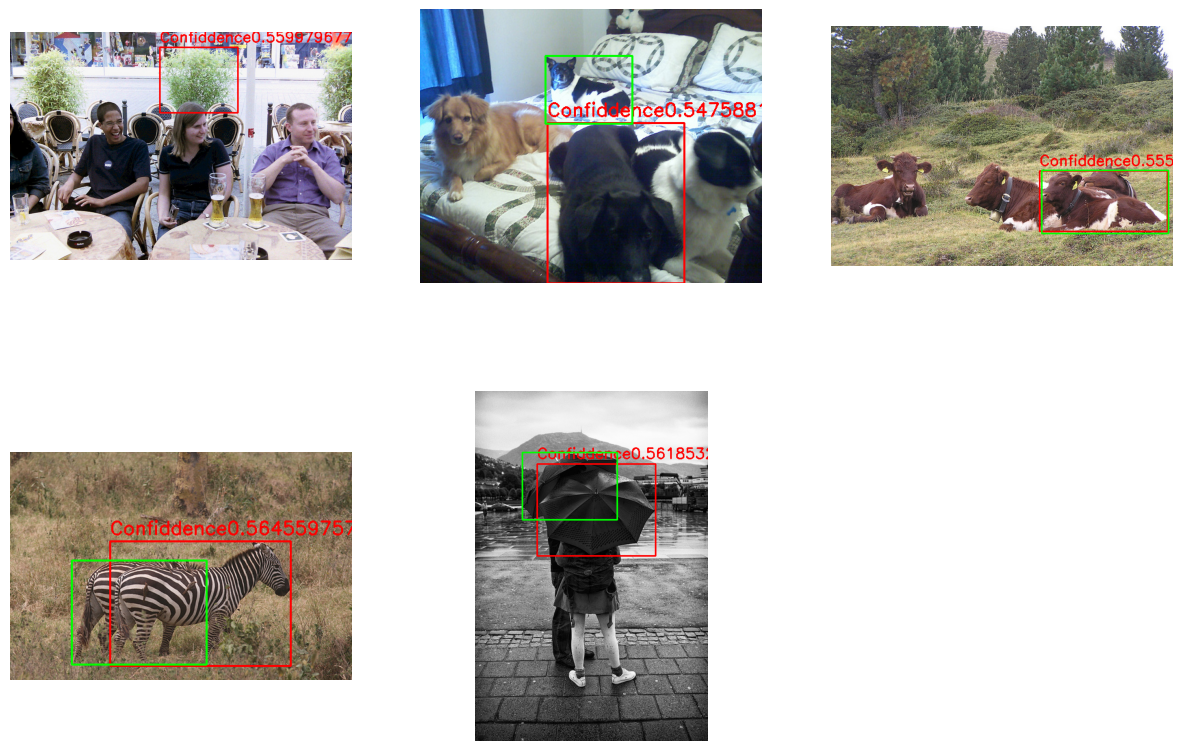

In [23]:
plot_images(proc)

# External Attention

## Model Pipeline

In [24]:
##########################################################
# YolottoClip - Just for Zero-Shotting the dataset
##########################################################
from  torch.cuda.amp import autocast
MOMENTUM = 0.1 #Default should be 3e-4
class ConvBNReLU(nn.Module):
    '''Module for the Conv-BN-ReLU tuple.'''

    def __init__(self, c_in, c_out, kernel_size, stride, padding, dilation):
        super(ConvBNReLU, self).__init__()
        self.conv = nn.Conv2d(
                c_in, c_out, kernel_size=kernel_size, stride=stride, 
                padding=padding, dilation=dilation, bias=False)
        self.bn = nn.SyncBatchNorm(c_out, momentum=MOMENTUM)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

class External_attention(nn.Module):

    '''
    Arguments:
        c (int): The input and output channel number.
    '''
    def __init__(self, c):
        super(External_attention, self).__init__()
        
        self.conv1 = nn.Conv2d(c, c, 1) #Convolution to linear layer
        self.al4 = 0
        self.k = 64
        self.fc0 = ConvBNReLU(2048, 512, 3, 1, 1, 1)
        self.linear_0 = nn.Conv1d(c, self.k, 1, bias=False)
        self.norm_layer = nn.SyncBatchNorm(c, momentum=MOMENTUM)
        self.linear_1 = nn.Conv1d(self.k, c, 1, bias=False)
        self.linear_1.weight.data = self.linear_0.weight.data.permute(1, 0, 2)        
        self.fc1 = nn.Sequential(
            ConvBNReLU(512, 256, 3, 1, 1, 1),
            nn.Dropout2d(p=0.1))
        self.conv2 = nn.Sequential(
            nn.Conv2d(c, c, 1, bias=False),
            self.norm_layer)    
        self.fc2 = nn.Conv2d(256, 80, 1)   
        self.final_linear = nn.Sequential(
            nn.Linear(3920, 1024)
        )
        
        for m in self.modules():
            if isinstance(m, nn.Conv2d): # Kaiming Initialiaztion
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, nn.Conv1d):# He Initialization
                n = m.kernel_size[0] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, _BatchNorm): # BatchNorm Initialization all setted to 1
                m.weight.data.fill_(1)
                if m.bias is not None:
                    m.bias.data.zero_()

    # We need to compute the tensor one example by another in order for the memory units to 
    # grasp possible correlations between the different examples
    def process_features(self, tensor, shift=1):
        cycled_tensor = torch.roll(tensor, shifts=shift, dims=0)
        outputs = []
        
        for i in range(cycled_tensor.shape[0]):
            # Extract each slice along the first dimension
            tensor_slice = cycled_tensor[i]
            
            # Pass the slice through the model's forward method
            output = self.forward(tensor_slice.unsqueeze(0))  # Unsqueeze to add the batch dimension back
            
            # Store the output
            outputs.append(output)
        
        # Combine the outputs back into a single tensor if needed
        combined_output = torch.cat(outputs, dim=0)
        
        return combined_output


    def forward(self, x):
        # print(x.shape)
        x = self.fc0(x)
        idn = x
        x = self.conv1(x)

        b, c, h, w = x.size()
        n = h*w
        x = x.view(b, c, n)   # b * c * n 

        attn = self.linear_0(x) # b, k, n
        attn = F.softmax(attn, dim=-1) # b, k, n

        attn = attn / (1e-9 + attn.sum(dim=1, keepdim=True)) #  # b, k, n
        x = self.linear_1(attn) # b, c, n

        x = x.view(b, c, h, w)
        x = self.conv2(x)
        x = x + idn
        x = F.relu(x)
        x = self.fc1(x)
        x = self.fc2(x)
        x = x.view(1, -1)
        # print(x.shape)
        x = self.final_linear(x)

        return x
    
class ExternalYoloClip(nn.Module):
    def __init__(self, clip_model, clip_preprocess, device = 'cuda'):
        super(ExternalYoloClip, self).__init__()
        #self.yolo = YOLO("yolov8n.pt").eval()
        self.EA = External_attention(512).to(device)
        self.clip_model, self.clip_preprocess = clip_model, clip_preprocess
        self.clip_model.visual.attnpool = torch.nn.Identity() # Remove last attention layer of Clip - Resnet50
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))
        self.processing = []
        self.similarities = []
        self.device = device

    def encode_image(self, image):
        # Encode the image using the CLIP model
        with torch.no_grad():
            image_features = self.clip_model.encode_image(image)

        return image_features
    
    # def preprocess_images(self, cropped_images):
    #     # preprocess with CLIP each cropped PIL image(converts each image in a image
    #     # of size [3,224,224])
    #     processing = []
    #     for image in cropped_images:
    #         processed_img = self.clip_preprocess(image).to(self.device)
    #         # proc = self.clip_model.encode_image(processed_img)
    #         processing.append(processed_img)
    #     preprocessed = torch.tensor(np.stack(processing))
    #     # preprocessed = torch.stack(processing).to(self.device) # return a single tensor
    #     return preprocessed

    def encode_text(self, text):
        with torch.no_grad():
            text_features = self.clip_model.encode_text(text)
        return text_features
    
    # def hook_fn(self, module, input, output):
    #     self.al = output

    def forward(self, images, text):
        # print(images.shape)
        #bl = 0 # input of layer4 of CLIP's ResNet
        #print(len(images))
        # hook_handle = clip_model.visual.layer4.register_forward_hook(self.hook_fn) # handle to retrieve output
        image_features = self.encode_image(images)
        # print(image_features)
        # print(70*'-')
        # # print(self.al.shape)
        with autocast():
            image_features = self.EA.process_features(image_features)
        # print(image_features)
        # print(70*'-')
        # print(image_features.shape)
        # print(70*'-')

        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        with autocast():
            text_features = self.encode_text(text)
        # temp = []
        # temp.append(text_features)
        # temp.append(text_features)
        # temp.append(text_features)
        # text_features2 = torch.cat(temp, dim=0)
        # print(text_features)
        # print(70*'-')
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        # text_features2 = text_features2 / text_features2.norm(dim=-1, keepdim=True)
        logit_scale = self.logit_scale.exp()
        # normalized featuresim
        similarity = (image_features @ text_features.t())
        # print(similarity.cpu())
        # similarity = (image_features @ text_features2.t())
        # print(similarity.cpu())
        scaled_similarity = logit_scale * similarity
        logits_per_image = scaled_similarity
        logits_per_text = scaled_similarity.t()

        # print(text_features.shape)
        # # cosine similarity as logits
        # logits_per_image = logit_scale * (image_features @ text_features.t())
        # print("Logits = " + str(logits_per_image))
        # logits_per_text = logits_per_image.t()

        # shape = [global_batch_size, global_batch_size]
        # hook_handle.remove()

        return logits_per_image, logits_per_text

## utils

In [25]:
def train_Pipeline(model):
    model.clip_model.train()
    model.EA.train()

def eval_Pipeline(model):
    model.clip_model.eval()
    model.EA.eval()

In [26]:
current_time = datetime.now().strftime('%Y%m%d-%H%M%S')

In [27]:
run_dir = os.path.join(log_dir, current_time)
writer_training = SummaryWriter(run_dir + 'training', 'training')
writer_val = SummaryWriter(run_dir + 'eval', 'val')

In [28]:
def freeze_layers(model):
    for param in model.clip_model.parameters():
        param.requires_grad = False

def unfreeze_layers(model):
    for param in model.clip_model.parameters():
        param.requires_grad = True

## Parameters

In [29]:
NUM_EPOCHS = 10
count = 0
iou_threshold = 0.5
loss_meter = MetricMeter(name = 'TrainingEA', threshold=iou_threshold)

running_loc_acc = 0.0
correct_bboxes = 0
overall = 0
semantic = 0
semantic_similarity = 0
running_ga = 0
sem = 0
loc_acc = 0
model = ExternalYoloClip(clip_model,clip_preprocess,device=device)

lr = 0.0001
# wd = 0.002 # best run so far
wd = 0.001
alpha = 1 # to decrease lr over time

In [30]:
cost = nn.CrossEntropyLoss()
optimizer = torch.optim.Adadelta(model.parameters(), lr=lr, weight_decay = wd)
optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=wd)

## training / val step

In [31]:
cumulative_accuracy = 0.0
cumulative_loss = 0.0
overall = 0
errors = 0

score_temp = 10
val_e = 0

test_cumulative_accuracy = 0.0
test_cumulative_loss = 0.0
test_overall = 0
test_errors = 0

# Initialize lists to store metrics
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

# Freeze layers of the model if needed
freeze_layers(model)

# Training and evaluation loop
for i in range(NUM_EPOCHS):
    minibatch = 1
    cumulative_accuracy = 0.0
    cumulative_loss = 0.0
    overall = 0
    
    loop = tqdm(dataloader_train, position=0, leave=True)
    test_loop = tqdm(dataloader_test, position=0, leave=True)
    train_Pipeline(model)
    
    # Profiling the model
    with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=True, profile_memory=True, with_stack=True) as prof:
        for _, data in enumerate(loop):
            try:
                texts = data[0].squeeze(1).to(device)
                gts = data[1]
                clss = data[2]
                filename = data[3]
                images = data[4]

                with record_function("model_inference"):
                    optimizer.zero_grad()
                    li, lt = model.forward(images, texts)
                    ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
                    img_loss = cost(li, ground_truth)
                    desc_loss = cost(lt, ground_truth)
                    loss = (img_loss + desc_loss) / 2

                with record_function("model_backward"):
                    loss.backward()
                    optimizer.step()

                overall += len(images)
                cumulative_loss += loss.item() * len(images)  # Scale by batch size
                _, predicted = li.max(dim=1)
                cumulative_accuracy += predicted.eq(ground_truth).sum().item()

                loss = cumulative_loss / overall 
                acc = cumulative_accuracy / overall

                writer_training.add_scalar("Loss/Minibathes", loss, minibatch)
                writer_training.add_scalar("Accuracy/Minibathes", acc, minibatch)
                minibatch += 1

                # Save the model if the current loss is the lowest
                if loss < score_temp:
                    score_temp = loss
                    torch.save(model.state_dict(), 'saves/EA.pt')
            except Exception as e:
                print(f"Error during training: {e}")
                pass

            loop.set_description(f"Training Epoch {i} values => Loss Iter = {loss}, Accuracy = {acc}")

    # Store metrics for plotting
    train_losses.append(loss)
    train_accuracies.append(acc)

    writer_training.add_scalar("Loss/Epoch", cumulative_loss / overall, i)
    writer_training.add_scalar("Accuracy/Epoch", cumulative_accuracy / overall, i)

    # Evaluation step every 5 epochs
    if i % 5 == 0:
        eval_Pipeline(model)
        test_cumulative_accuracy = 0.0
        test_cumulative_loss = 0.0
        test_overall = 0

        with torch.no_grad():
            for _, data in enumerate(test_loop):
                try:
                    texts = data[0].squeeze(1).to(device)
                    gts = data[1]
                    clss = data[2]
                    filename = data[3]
                    images = data[4]

                    li, lt = model.forward(images, texts)
                    ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
                    img_loss = cost(li, ground_truth)
                    desc_loss = cost(lt, ground_truth)
                    loss = (img_loss + desc_loss) / 2

                    test_overall += len(images)
                    test_cumulative_loss += loss.item() * len(images)
                    _, predicted = li.max(dim=1)
                    test_cumulative_accuracy += predicted.eq(ground_truth).sum().item()

                    loss = test_cumulative_loss / test_overall
                    acc = test_cumulative_accuracy / test_overall

                    writer_val.add_scalar("Loss/Minibathes", loss, minibatch)
                    writer_val.add_scalar("Accuracy/Minibathes", acc, minibatch)
                    minibatch += 1
                except Exception as e:
                    print(f"Error during evaluation: {e}")
                    pass

                test_loop.set_description(f"Testing Epoch {i}. Values => Loss Iter = {loss}, Accuracy = {acc}")

        # Store evaluation metrics for plotting
        test_losses.append(loss)
        test_accuracies.append(acc)

        writer_val.add_scalar("Loss/Epoch", test_cumulative_loss / test_overall, val_e)
        writer_val.add_scalar("Accuracy/Epoch", test_cumulative_accuracy / test_overall, val_e)
        val_e += 1


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

/Users/mattiacarolo/.pyenv/versions/3.9.6/envs/bagigio/lib/python3.9/site-packages/torch/autograd/profiler.py:228: UserWarning: CUDA is not available, disabling CUDA profiling
  warn("CUDA is not available, disabling CUDA profiling")
/Users/mattiacarolo/.pyenv/versions/3.9.6/envs/bagigio/lib/python3.9/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
[W CPUAllocator.cpp:249] Memory block of unknown size was allocated before the profiling started, profiler results will not include the deallocation event
/Users/mattiacarolo/.pyenv/versions/3.9.6/envs/bagigio/lib/python3.9/site-packages/torch/amp/autocast_mode.py:250: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Error during training: Parent directory saves does not exist.


  0%|          | 0/1 [00:00<?, ?it/s]

...

Error during training: Parent directory saves does not exist.


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

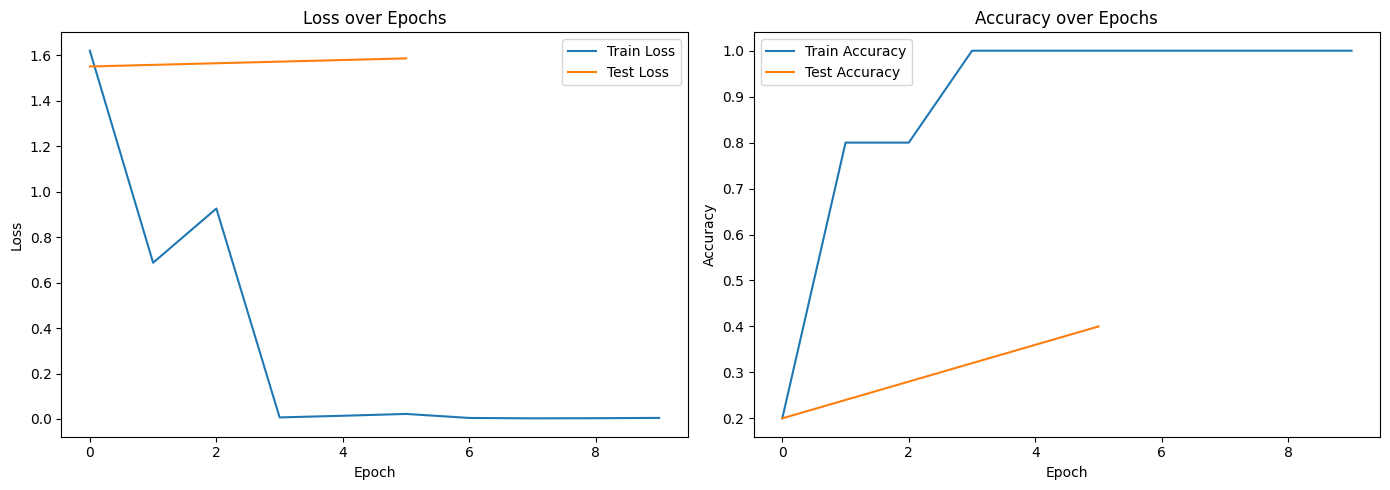

In [32]:
# Plotting metrics
plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(range(0, NUM_EPOCHS, 5), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(range(0, NUM_EPOCHS, 5), test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

In [230]:
# Print profiling results
print(prof.key_averages().table(sort_by="self_cpu_time_total", row_limit=10))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                             aten::_slow_conv2d_forward        36.77%     279.524ms        36.87%     280.285ms       3.014ms     240.21 Mb    -465.80 Mb            93  
                                        model_inference        10.57%      80.345ms        74.62%     567.293ms     567.293ms     -52.37 Mb    -767.18 Mb             1  
                                            aten::addmm         9.41%      71.511ms         9.74%      74.052ms       1.397ms      81.23 Mb      81.23

In [231]:
writer_training.close()
writer_val.close()

In [232]:
def infer_bboxes(image_path, yolo):
    yolo = yolo
    #print(image_path)
    results = yolo(image_path, verbose=False)
    # print(results[0])
    bboxes = results[0].boxes.xyxy
    #cls = results[0].boxes.cls
    return bboxes

def get_candidate_crop(text,path,yolo):
    images = []
    best_score = 0
    best_bbox = None
    boxes = infer_bboxes(path, yolo)
    for bbox in boxes:
        temp = cv2.imread(path)
        image = np.zeros((temp.shape[0], temp.shape[1], temp.shape[2]), dtype=np.uint8)
        image[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])] = temp[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])]
        image = clip_preprocess(Image.fromarray(image)).to(device)
        #image = image.unsqueeze(0)
        images.append(image)
    images = torch.stack(images)
    #print(images.shape)
    with torch.no_grad():
        logits_per_image, logits_per_text = model(images, text)
        #matching_score = logits_per_text.cpu().numpy()[0]
        probs = torch.sigmoid(logits_per_text)
        best = torch.max(probs)
        idx = torch.argmax(probs)

        if best.float() > best_score:
                best_score = best.float()
                best_bbox = boxes[idx] 
                #print('bbox found is = ' + str(best_bbotest_cumulative_accuracyx))
    
    return best_score, best_bbox


In [234]:
cumulative_accuracy = 0.0
cumulative_loss = 0.0
overall = 0
errors = 0
yolo = YOLO('yolov8n.pt')
cumulative_iou = 0.0
cumulative_recall = 0.0
cumulative_sim = 0.0
iou_threshold = 0.5
correct_bboxes = 0
proc = []

eval_loop = tqdm(dataloader_eval, position=0, leave=True)
eval_Pipeline(model)
with torch.no_grad():
    for _,data in enumerate(eval_loop):
        try:
            scores = []
            bboxes = []

            texts = data[0]
            texts = texts.squeeze(1).to(device)
            #images = data[1].to(device)
            gts = data[1]
            clss = data[2]
            filename = data[3]
            images = []
            
            for x in filename:
                temp = Image.open(x)
                image = clip_preprocess(temp).to(device)
                images.append(image)

            images = torch.stack(images)
            batch = len(images)
            overall += batch

            for i in range(batch):
                stack = [texts[i]]
                stacks = torch.stack(stack)
                score, ebbox = get_candidate_crop(stacks, filename[i],yolo)
                #print(gts[i])
                # scores.append(score)
                # bboxes.append(ebbox)
                iou = compute_iou(ebbox, gts[i])
                cumulative_iou += iou
                if(iou > iou_threshold):
                    #compare_candidate_bbox(filename,bbox_e, bbox_gt)
                    correct_bboxes += 1
                similarity = score / 100
                cumulative_sim += score

                loc_acc = cumulative_iou / overall
                ga = cumulative_accuracy / overall
                semsim = cumulative_sim / overall 

                if(len(proc)<9):
                    proc.append(draw_bboxes(filename[i],ebbox,gts[i],score.item()))
        except:    
            pass

        eval_loop.set_description(f"Localization accuracy = {loc_acc}, Grounding Accuracy = {ga}, Semantic Similarity = {semsim}")


  0%|          | 0/1 [00:00<?, ?it/s]

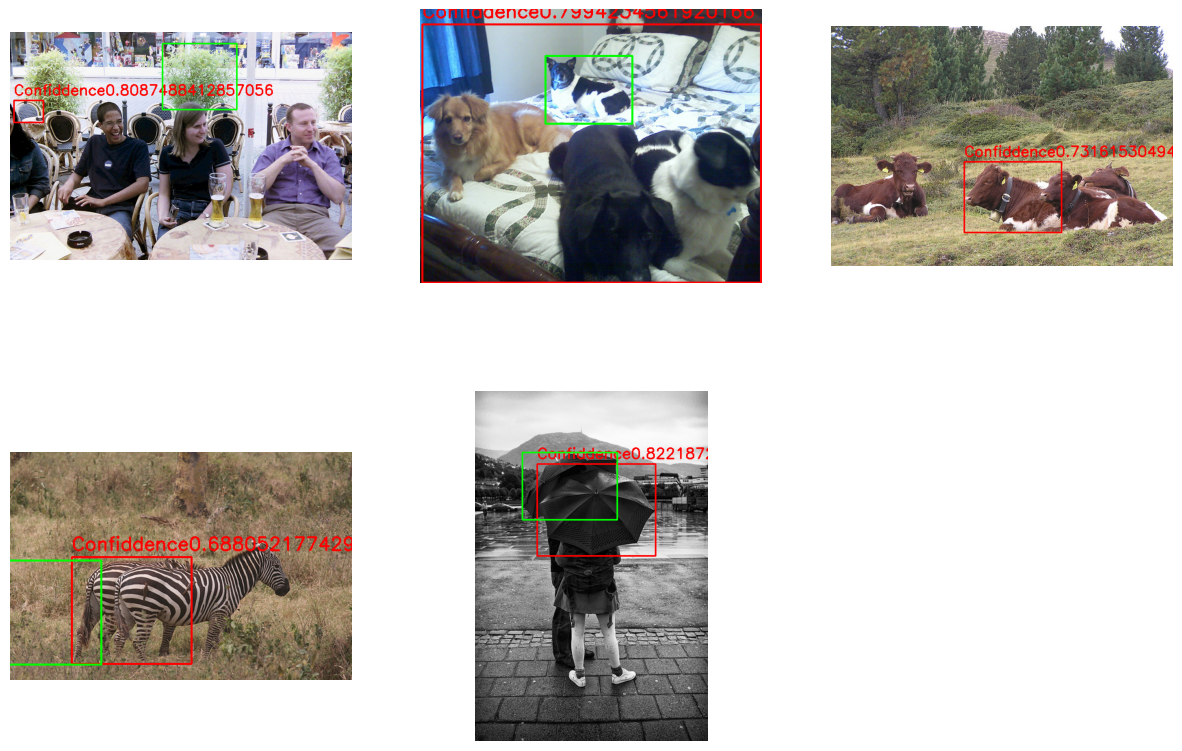

In [235]:
plot_images(proc)